# Movie Review Prediction - exploratory analysis

Reshapes `movies_cleaned.csv` (700 Bollywood films, 47 lead actors, 2000-2026) from one row
per movie to one row per actor, and asks whether a lead actor's record predicts a good
review. Three sections: per-actor averages and shrinkage, whether `rating` is normal within
an actor, and the era drift hiding inside actor means.

Everything here is **exploratory**: features are built over all 700 rows at once, so they
leak. `feature_engineering.py` rebuilds them leak-free for modelling.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib as mpl


In [2]:
df = pd.read_csv('movies_cleaned.csv')

In [3]:
df.head()

,movie_title,lead_actor,sentiment,rating,year,release_date,language,genre,director,actor_2,actor_3,music_director,critic,review_url
0,Housefull 3,Akshay Kumar,negative,3.0,2016,"June 3, 2016",Hindi,Comedy,"Sajid Samji, Farhad Samji",Riteish Deshmukh,Abhishek Bachchan,"Toshi Sabri, Sharib Sabri, Mika Singh, Sohail ...",Bollywood Hungama News Network,https://www.bollywoodhungama.com/movie/housefu...
1,Rustom,Akshay Kumar,negative,3.0,2016,"August 11, 2016",Hindi,"Romance, Thriller",Tinu Suresh Desai,Ileana D'Cruz,Esha Gupta,"Ankit Tiwari, Raghav Sachar, Jeet Ganguly, Ark...",Bollywood Hungama News Network,https://www.bollywoodhungama.com/movie/rustom-...
2,Jolly LLB 2,Akshay Kumar,positive,3.5,2017,"February 10, 2017",Hindi,"Comedy, Drama",Subhash Kapoor,Huma Qureshi,Saurabh Shukla,"Chirantan Bhatt, Manj Musik, Vishal Khurana, M...",Bollywood Hungama News Network,https://www.bollywoodhungama.com/movie/jolly-l...
3,Toilet - Ek Prem Katha,Akshay Kumar,negative,3.0,2017,"August 11, 2017",Hindi,"Comedy, Drama",Shree Narayan Singh,Bhumi Pednekar,Divyenndu,"Parampara Band, Vickey Prasad, Manas, Shikhar,...",Bollywood Hungama News Network,https://www.bollywoodhungama.com/movie/toilet-...
4,Gold,Akshay Kumar,positive,4.0,2018,"August 14, 2018",Hindi,"Biographical, Sports",Reema Kagti,Mouni Roy,Kunal Kapoor,"Sachin Sanghvi, Jigar Saraiya, Tanishk Bagchi,...",Bollywood Hungama News Network,https://www.bollywoodhungama.com/movie/gold/cr...


In [4]:
df


,movie_title,lead_actor,sentiment,rating,year,release_date,language,genre,director,actor_2,actor_3,music_director,critic,review_url
0,Housefull 3,Akshay Kumar,negative,3.0,2016,"June 3, 2016",Hindi,Comedy,"Sajid Samji, Farhad Samji",Riteish Deshmukh,Abhishek Bachchan,"Toshi Sabri, Sharib Sabri, Mika Singh, Sohail ...",Bollywood Hungama News Network,https://www.bollywoodhungama.com/movie/housefu...
1,Rustom,Akshay Kumar,negative,3.0,2016,"August 11, 2016",Hindi,"Romance, Thriller",Tinu Suresh Desai,Ileana D'Cruz,Esha Gupta,"Ankit Tiwari, Raghav Sachar, Jeet Ganguly, Ark...",Bollywood Hungama News Network,https://www.bollywoodhungama.com/movie/rustom-...
2,Jolly LLB 2,Akshay Kumar,positive,3.5,2017,"February 10, 2017",Hindi,"Comedy, Drama",Subhash Kapoor,Huma Qureshi,Saurabh Shukla,"Chirantan Bhatt, Manj Musik, Vishal Khurana, M...",Bollywood Hungama News Network,https://www.bollywoodhungama.com/movie/jolly-l...
3,Toilet - Ek Prem Katha,Akshay Kumar,negative,3.0,2017,"August 11, 2017",Hindi,"Comedy, Drama",Shree Narayan Singh,Bhumi Pednekar,Divyenndu,"Parampara Band, Vickey Prasad, Manas, Shikhar,...",Bollywood Hungama News Network,https://www.bollywoodhungama.com/movie/toilet-...
4,Gold,Akshay Kumar,positive,4.0,2018,"August 14, 2018",Hindi,"Biographical, Sports",Reema Kagti,Mouni Roy,Kunal Kapoor,"Sachin Sanghvi, Jigar Saraiya, Tanishk Bagchi,...",Bollywood Hungama News Network,https://www.bollywoodhungama.com/movie/gold/cr...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Jodi Breakers,R Madhavan,negative,3.0,2012,"February 24, 2012",Hindi,Romance,Ashwini Chaudhary,Bipasha Basu,Mazhar Syed,"Salim Merchant, Sulaiman Merchant",Taran Adarsh,https://www.bollywoodhungama.com/movie/jodi-br...
696,Rocketry - The Nambi Effect,R Madhavan,negative,3.0,2022,"June 30, 2022",Hindi,"Biographical, Sci-Fi",R Madhavan,Nambi Narayanan,Shah Rukh Khan,NaN,Bollywood Hungama News Network,https://www.bollywoodhungama.com/movie/rocketr...
697,Mere Yaar Ki Shaadi Hai,Uday Chopra,negative,2.0,2002,"June 7, 2002",Hindi,"Drama, Romance",Sanjay Gadhvi,Jimmy Sheirgill,Tulip Joshi,Pritam Chakraborty,Taran Adarsh,https://www.bollywoodhungama.com/movie/mere-ya...
698,Supari,Uday Chopra,negative,1.0,2003,"June 20, 2003",Hindi,"Crime, Drama",Padam Kumar,Nauheed Cyrusi,Irrfan Khan,"Sandesh Shandilya, Shekhar Ravjianii, Vishal D...",Taran Adarsh,https://www.bollywoodhungama.com/movie/supari/...


In [5]:
# `year` stays in the frame - it is real signal, it just isn't a "score", so it
# doesn't belong in the same summary table as rating.
print(df.describe(exclude='number').T.to_string(), '\n')
df[['rating']].describe()

               count unique                                                                top freq
movie_title      700    699                                                            Ittefaq    2
lead_actor       700     47                                                         Ajay Devgn   53
sentiment        700      2                                                           negative  463
release_date     700    611                                                  December 15, 2000   23
language         700      1                                                              Hindi  700
genre            669    157                                                              Drama   41
director         697    370                                                       David Dhawan   14
actor_2          700    283                                                Kareena Kapoor Khan   24
actor_3          700    479                                                       Arshad Warsi   11


,rating
count,700.000000
mean,2.712143
std,1.000177
min,1.000000
25%,2.000000
50%,2.500000
75%,3.500000
max,5.000000


<Axes: >

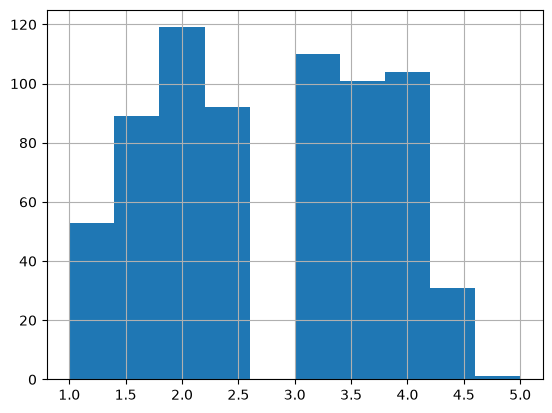

In [6]:
#Problem to be solved: Per lead actor find mean ratings and positive. 
df.rating.hist()

In [7]:
#Considering only the lead Actor

# Per-actor analysis

700 movies average **2.71**, which says nothing about whether a given lead actor predicts a
good review - so the frame is reshaped to one row per actor. Three things drive what follows.

**Sentiment is not new information.** `sentiment == 'positive'` is exactly `rating >= 3.5`
for all 700 rows, asserted at [data_cleaning.py:78-79](data_cleaning.py#L78-L79). This
section therefore works from `rating` only; the next cell proves the identity.

**"Average" is two different numbers.** Averaging the `rating` column gives **2.712**, but
that lets Ajay Devgn's 53 films vote 53 times. Averaging the 47 *actor* means gives **2.659**,
one vote each. `MOVIE_MEAN` describes the movie population; `ACTOR_MEAN` is the shrinkage
target, since shrinkage guesses an *actor's* mean and that actor came from a pool of actors.

**Raw means rank noise at the top.** Ranveer Singh averages 3.88 across *four* films, Ajay
Devgn 3.09 across *53*. Shrinkage credits every actor with `M` imaginary average films:

    adj_mean = (n * actor's mean + M * ACTOR_MEAN) / (n + M)

**Why M = 15.** Empirical Bayes gives `0.841 / 0.197` = **4.3**, rejected here because at 4.3
a four-film actor keeps 48% of the say and Ranveer still finishes first - the exact artefact
shrinkage was meant to remove. `M = 15` encodes the domain rule instead: a career needs ~15
films before its average means anything. Ranveer lands at 2.91, 7th. Anything from 12 to 30
gives the same ordering.

Two features come out: continuous `adj_mean`, and a `tier` label from `n_movies >= 15`
crossed with `mean > 3`.


In [8]:
# --- chart chrome: one palette for every figure below -----------------------
SURFACE, INK, INK2, MUTED, GRID, AXIS = (
    '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7')

# Tiers are ordered (most to least confidently positive), so they get an ordinal
# single-hue ramp - dark = most confident - rather than four unrelated colours.
TIER_ORDER = ['proven_positive', 'promising', 'unproven', 'proven_weak']
TIER_COLOR = {'proven_positive': '#184f95', 'promising': '#2a78d6',
              'unproven': '#5598e7', 'proven_weak': '#86b6ef'}

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK2, 'text.color': INK,
    'axes.titlecolor': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.grid': True, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'figure.dpi': 110,
})

# --- sentiment carries no information beyond rating: prove it, then drop it ---
df['is_positive'] = (df['sentiment'] == 'positive').astype(int)
assert (df['is_positive'] == (df['rating'] >= 3.5).astype(int)).all(), \
    'sentiment is not a clean threshold on rating'
print('sentiment == (rating >= 3.5) for all %d rows - so the rest of this\n'
      'notebook works from rating alone.\n' % len(df))

# --- two averages, because two different questions get asked below -----------
# MOVIE_MEAN answers "what does a typical MOVIE score?" Every one of the 700 rows
#   votes once, so Ajay Devgn's 53 films vote 53 times. Right reference line for
#   any chart describing the movie population.
# ACTOR_MEAN answers "what does a typical ACTOR score?" Every actor votes once,
#   regardless of filmography length. Right shrinkage target, because shrinkage
#   guesses an ACTOR's true mean from the population of actors.
# They differ only because filmography lengths differ - they would be identical
# if every actor had the same number of movies.
MOVIE_MEAN = df['rating'].mean()                               # 2.712
ACTOR_MEAN = df.groupby('lead_actor')['rating'].mean().mean()  # 2.659

M = 15                              # prior weight - see the markdown above for why 15
MIN_PROVEN = 15                     # movies needed before a mean counts as established

print('%d movies | %d lead actors' % (len(df), df['lead_actor'].nunique()))
print('mean rating per movie %.3f | mean rating per actor %.3f  <- shrink target'
      % (MOVIE_MEAN, ACTOR_MEAN))

sentiment == (rating >= 3.5) for all 700 rows - so the rest of this
notebook works from rating alone.

700 movies | 47 lead actors
mean rating per movie 2.712 | mean rating per actor 2.659  <- shrink target


In [9]:
# One row per actor instead of one row per movie
actors = (df.groupby('lead_actor')
            .agg(n_movies=('rating', 'size'),
                 mean_rating=('rating', 'mean'),
                 median_rating=('rating', 'median'),
                 std_rating=('rating', 'std'),
                 min_rating=('rating', 'min'),
                 max_rating=('rating', 'max'),
                 first_year=('year', 'min'),
                 last_year=('year', 'max'))
            .assign(
                # standard error of the mean - how much this number can be trusted
                se=lambda t: t.std_rating / np.sqrt(t.n_movies),
                # shrunk mean: M pseudo-movies at the average-ACTOR level are
                # added to every actor, so a 4-movie record cannot outrank a
                # 50-movie one on noise alone. Target is ACTOR_MEAN, not
                # MOVIE_MEAN: we are guessing an actor's true mean, and that
                # actor was drawn from the population of actors, not of movies.
                adj_mean=lambda t: (t.n_movies * t.mean_rating + M * ACTOR_MEAN)
                                   / (t.n_movies + M),
                tier=lambda t: np.select(
                    [(t.n_movies >= MIN_PROVEN) & (t.mean_rating > 3),
                     (t.n_movies < MIN_PROVEN) & (t.mean_rating > 3),
                     (t.n_movies >= MIN_PROVEN)],
                    ['proven_positive', 'promising', 'proven_weak'],
                    default='unproven'))
            .sort_values('adj_mean', ascending=False))

assert actors.n_movies.sum() == len(df), 'lost or duplicated movies'
assert len(actors) == df.lead_actor.nunique()
assert actors[['adj_mean', 'tier']].notna().all().all()

print(actors.tier.value_counts().to_string(), '\n')
actors[['n_movies', 'mean_rating', 'std_rating', 'se', 'adj_mean', 'tier']].round(3)

tier
unproven           18
proven_weak        16
promising           7
proven_positive     6 



,n_movies,mean_rating,std_rating,se,adj_mean,tier
lead_actor,,,,,,
Akshay Kumar,27,3.315,0.681,0.131,3.080,proven_positive
Ajay Devgn,53,3.094,0.961,0.132,2.998,proven_positive
Salman Khan,40,3.062,1.183,0.187,2.952,proven_positive
Shah Rukh Khan,29,3.103,1.291,0.240,2.952,proven_positive
Hrithik Roshan,22,3.114,1.144,0.244,2.929,proven_positive
John Abraham,27,3.074,0.896,0.172,2.926,proven_positive
Ranveer Singh,4,3.875,0.479,0.239,2.915,promising
Ranbir Kapoor,8,3.375,1.026,0.363,2.908,promising
Priyanka Chopra Jonas,6,3.333,0.606,0.247,2.851,promising


In [10]:
# Put the actor-level features back on the movie rows, ready for modelling
df = df.merge(actors[['n_movies', 'mean_rating', 'std_rating', 'adj_mean', 'tier']]
              .rename(columns={'mean_rating': 'actor_mean_rating',
                               'std_rating': 'actor_std_rating'}),
              left_on='lead_actor', right_index=True, how='left')

assert len(df) == 700 and df['adj_mean'].notna().all()
df[['movie_title', 'lead_actor', 'year', 'rating',
    'n_movies', 'actor_mean_rating', 'adj_mean', 'tier']].head(10)

,movie_title,lead_actor,year,rating,n_movies,actor_mean_rating,adj_mean,tier
0,Housefull 3,Akshay Kumar,2016,3.0,27,3.314815,3.080476,proven_positive
1,Rustom,Akshay Kumar,2016,3.0,27,3.314815,3.080476,proven_positive
2,Jolly LLB 2,Akshay Kumar,2017,3.5,27,3.314815,3.080476,proven_positive
3,Toilet - Ek Prem Katha,Akshay Kumar,2017,3.0,27,3.314815,3.080476,proven_positive
4,Gold,Akshay Kumar,2018,4.0,27,3.314815,3.080476,proven_positive
5,Pad Man,Akshay Kumar,2018,4.0,27,3.314815,3.080476,proven_positive
6,Good Newwz,Akshay Kumar,2019,4.0,27,3.314815,3.080476,proven_positive
7,Housefull 4,Akshay Kumar,2019,2.0,27,3.314815,3.080476,proven_positive
8,Mission Mangal,Akshay Kumar,2019,4.5,27,3.314815,3.080476,proven_positive
9,Laxmii,Akshay Kumar,2020,2.0,27,3.314815,3.080476,proven_positive


> ### Leakage warning - read before modelling
>
> `adj_mean` and `actor_mean_rating` are built from `rating`, and `sentiment` **is**
> `rating >= 3.5`. Computed over all 700 rows as they are here, every movie has contributed
> to its own feature - for a 4-movie actor that is 25% of the feature leaking the answer.
>
> Fine for exploration, which is all this notebook does. `feature_engineering.py` recomputes
> these from each actor's *earlier* films only. Shrinkage at `M = 15` dampens the leak but
> does not fix it.


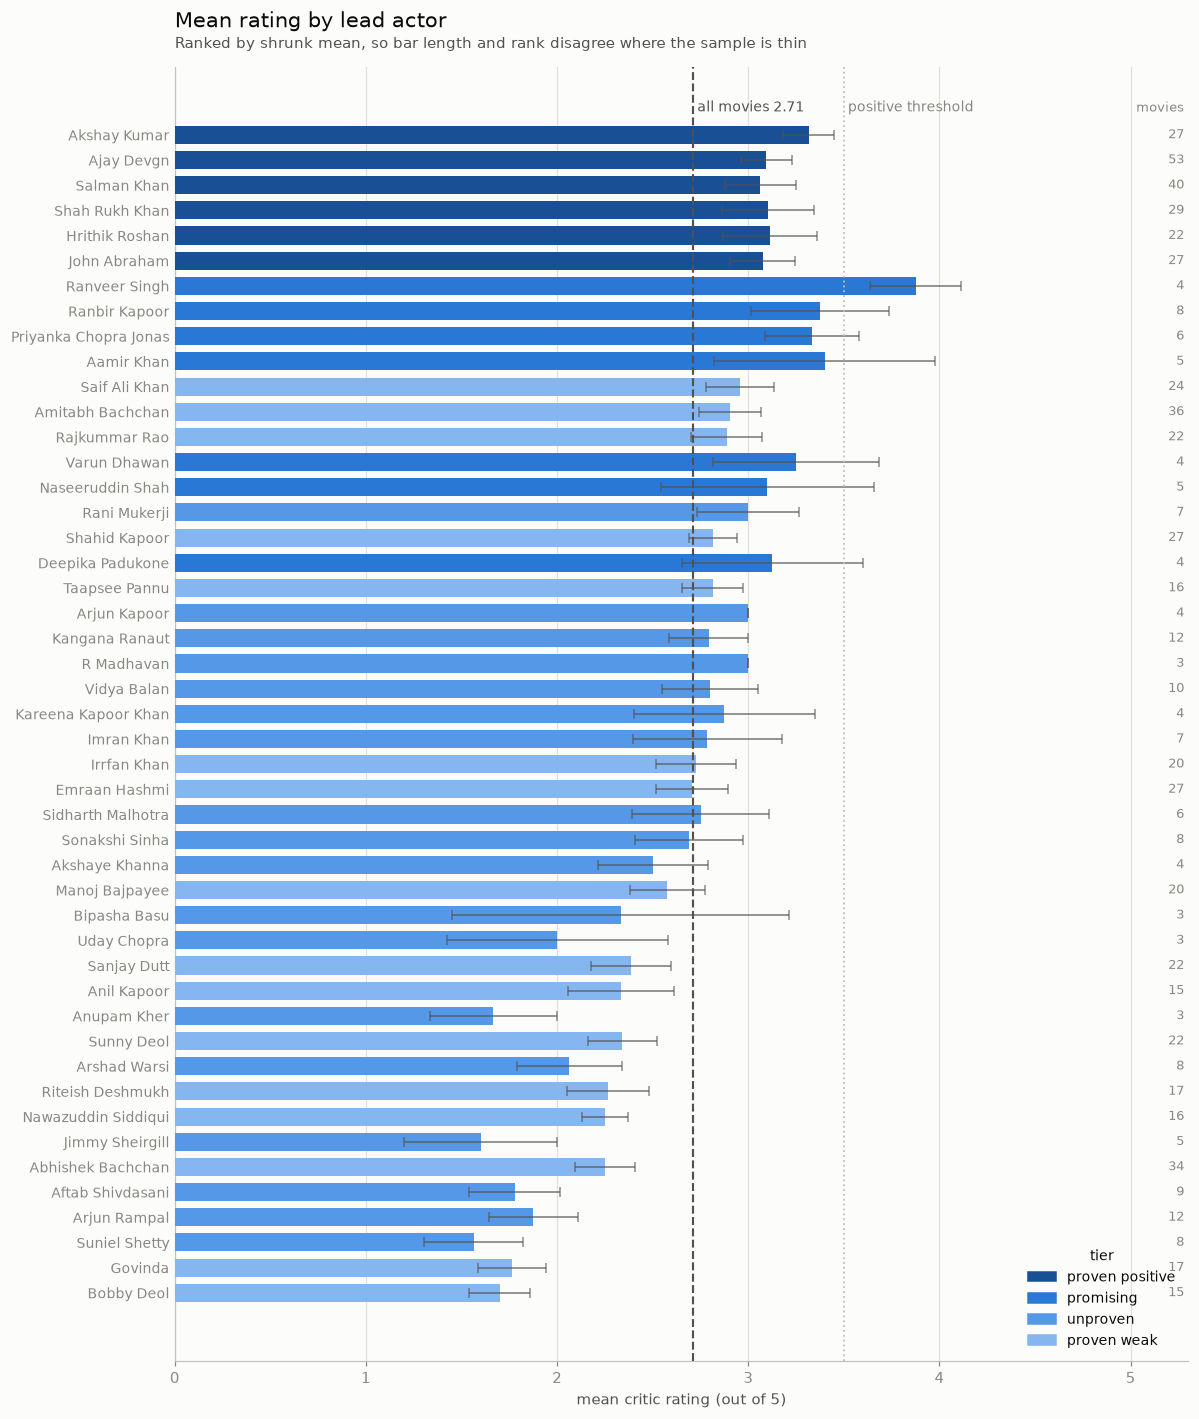

In [11]:
# Figure 1 - mean rating per actor
a = actors.loc[actors.index[::-1]]        # barh draws bottom-up, so reverse
fig, ax = plt.subplots(figsize=(11, 13))

ax.barh(a.index, a.mean_rating, height=0.72,
        color=[TIER_COLOR[t] for t in a.tier], zorder=3)
ax.errorbar(a.mean_rating, a.index, xerr=a.se.fillna(0), fmt='none',
            ecolor=INK2, elinewidth=1.2, capsize=3, alpha=0.65, zorder=4)

# sample size as its own right-hand column, so it never collides with the marks
for y, n in enumerate(a.n_movies):
    ax.text(5.28, y, '%d' % n, va='center', ha='right', fontsize=8.5, color=MUTED)
ax.text(5.28, len(a) - 0.2, 'movies', va='bottom', ha='right',
        fontsize=8.5, color=MUTED)

# label says "all movies", so this is the movie-weighted average
ax.axvline(MOVIE_MEAN, color=INK2, lw=1.4, ls='--', zorder=5)
ax.text(MOVIE_MEAN, len(a) - 0.2, ' all movies %.2f' % MOVIE_MEAN,
        fontsize=9, color=INK2, va='bottom')
ax.axvline(3.5, color=AXIS, lw=1.2, ls=':', zorder=5)
ax.text(3.5, len(a) - 0.2, ' positive threshold', fontsize=9, color=MUTED,
        va='bottom')

ax.set_xlim(0, 5.3)
ax.set_xticks(np.arange(0, 5.1, 1))
ax.set_xlabel('mean critic rating (out of 5)')
ax.set_title('Mean rating by lead actor', fontsize=14, pad=26, loc='left')
ax.text(0, 1.012, 'Ranked by shrunk mean, so bar length and rank disagree '
        'where the sample is thin', transform=ax.transAxes,
        fontsize=9.5, color=INK2, va='bottom')
ax.set_ylabel('')
ax.xaxis.grid(True); ax.yaxis.grid(False)
ax.tick_params(axis='y', labelsize=9, length=0)

handles = [plt.Rectangle((0, 0), 1, 1, color=TIER_COLOR[t]) for t in TIER_ORDER]
ax.legend(handles, [t.replace('_', ' ') for t in TIER_ORDER],
          loc='lower right', frameon=False, fontsize=9, title='tier',
          title_fontsize=9)

fig.tight_layout()
plt.show()

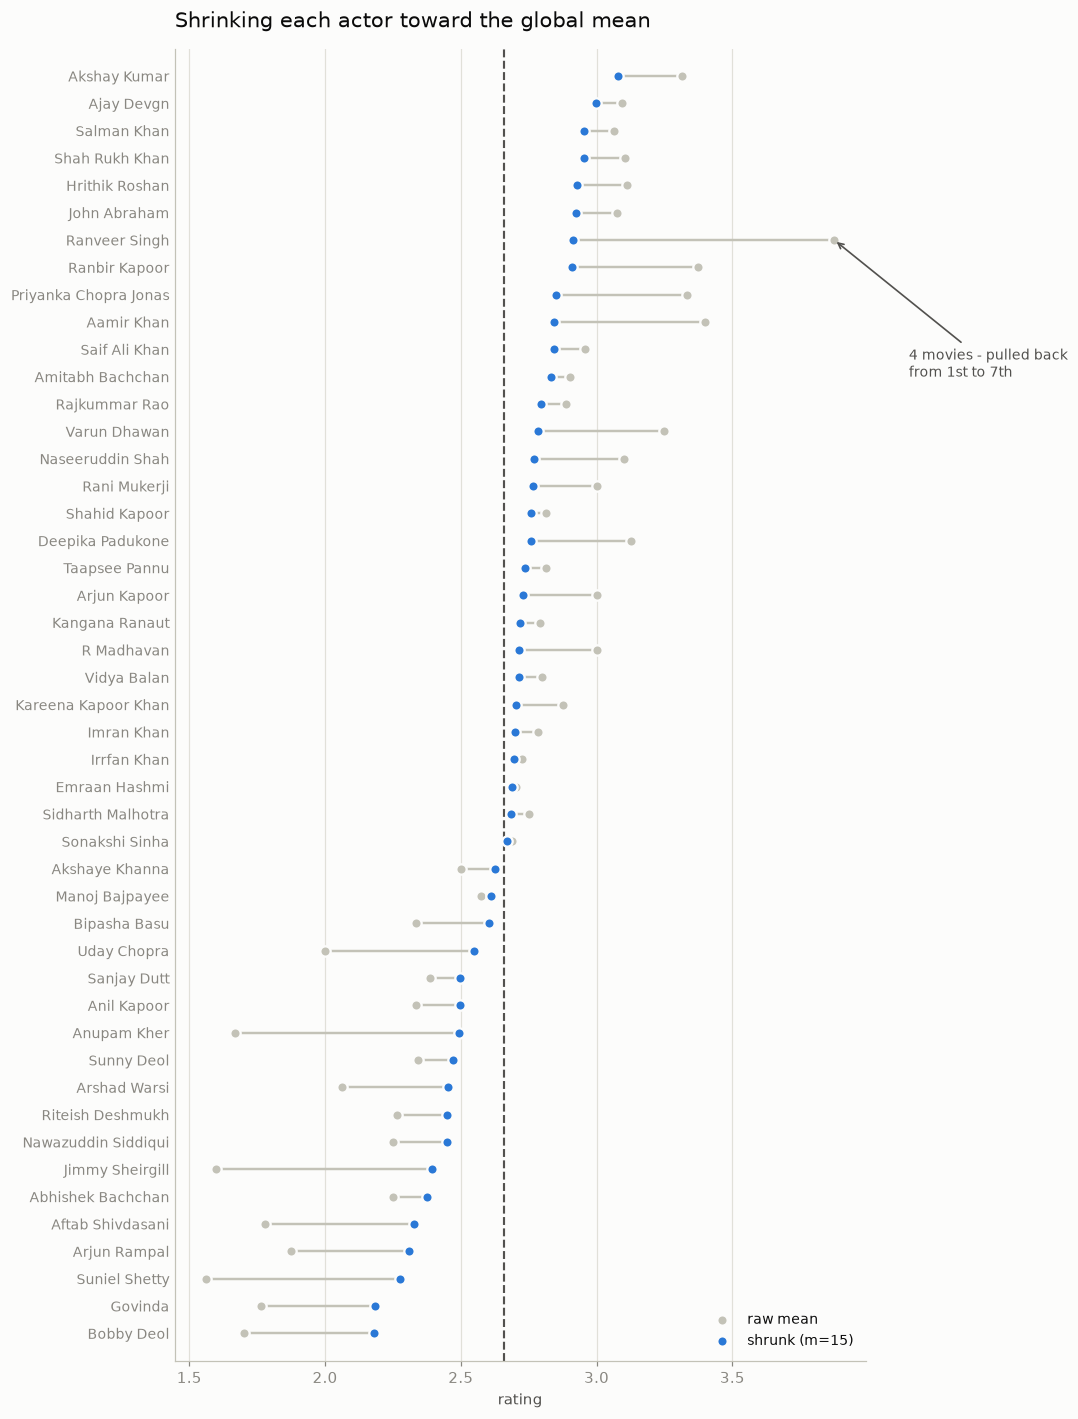

In [12]:
# Figure 2 - what shrinkage actually did to each actor
fig, ax = plt.subplots(figsize=(10, 13))

for y, (name, row) in enumerate(a.iterrows()):
    ax.plot([row.mean_rating, row.adj_mean], [y, y],
            color=AXIS, lw=1.6, zorder=2, solid_capstyle='round')
ax.scatter(a.mean_rating, range(len(a)), s=46, color=AXIS,
           edgecolor=SURFACE, lw=1.5, zorder=3, label='raw mean')
ax.scatter(a.adj_mean, range(len(a)), s=46, color='#2a78d6',
           edgecolor=SURFACE, lw=1.5, zorder=4, label='shrunk (m=%d)' % M)
# this figure shows dots converging on the SHRINKAGE TARGET, so the line has to
# be that target (ACTOR_MEAN) - drawing MOVIE_MEAN here would put the line where
# the blue dots demonstrably do not converge
ax.axvline(ACTOR_MEAN, color=INK2, lw=1.4, ls='--', zorder=1)

ax.set_yticks(range(len(a))); ax.set_yticklabels(a.index, fontsize=9)
ax.set_ylim(-1, len(a))
ax.set_xlabel('rating')
ax.set_title('Shrinking each actor toward the global mean',
             fontsize=14, pad=14, loc='left')
ax.xaxis.grid(True); ax.yaxis.grid(False)
ax.tick_params(axis='y', length=0)
ax.legend(loc='lower right', frameon=False, fontsize=9)

# call out the actor the correction is really about
if 'Ranveer Singh' in a.index:
    ry = list(a.index).index('Ranveer Singh')
    ax.annotate('4 movies - pulled back\nfrom 1st to %dth'
                % (list(actors.index).index('Ranveer Singh') + 1),
                xy=(a.mean_rating.iloc[ry], ry), xytext=(4.15, ry - 5),
                fontsize=9, color=INK2,
                arrowprops=dict(arrowstyle='->', color=INK2, lw=1.1))

fig.tight_layout()
plt.show()

# Long lines = thin filmographies being pulled back toward average.
# Short lines = actors with enough movies that the data speaks for itself.

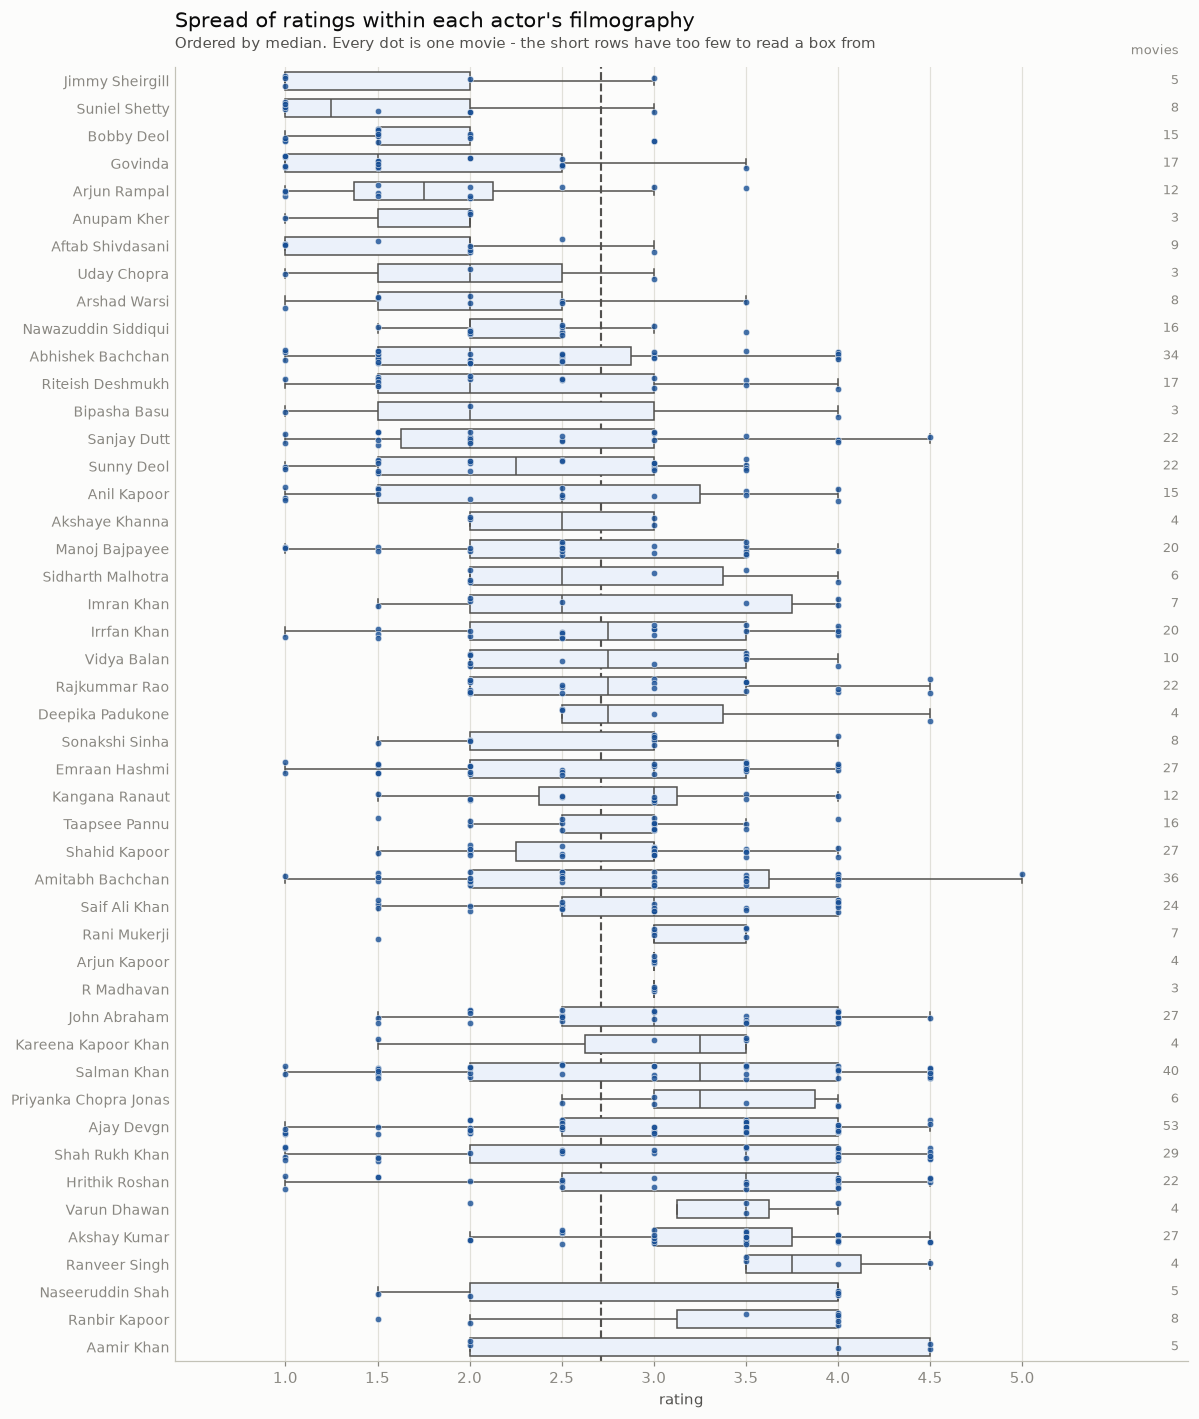

In [13]:
# Figure 3 - the spread behind each mean
# median alone leaves dozens of ties on a 9-value scale, which scrambles the
# order; the mean breaks them so the chart reads top-to-bottom
med_order = actors.sort_values(['median_rating', 'mean_rating']).index

fig, ax = plt.subplots(figsize=(11, 13))
sns.boxplot(data=df, y='lead_actor', x='rating', order=med_order, ax=ax,
            color='#e8f1fd', width=0.66, fliersize=0,
            linecolor='#52514e', linewidth=1.0)
sns.stripplot(data=df, y='lead_actor', x='rating', order=med_order, ax=ax,
              color='#184f95', size=4.2, alpha=0.8, jitter=0.26,
              edgecolor=SURFACE, linewidth=0.4)

ax.axvline(MOVIE_MEAN, color=INK2, lw=1.4, ls='--', zorder=1)  # movie-level chart
ax.set_xlim(0.4, 5.9)
ax.set_xticks(np.arange(1, 5.5, 0.5))
ax.set_xlabel('rating'); ax.set_ylabel('')
ax.set_title("Spread of ratings within each actor's filmography",
             fontsize=14, pad=26, loc='left')
ax.text(0, 1.012, 'Ordered by median. Every dot is one movie - the short rows '
        'have too few to read a box from', transform=ax.transAxes,
        fontsize=9.5, color=INK2, va='bottom')
ax.xaxis.grid(True); ax.yaxis.grid(False)
ax.tick_params(axis='y', labelsize=9, length=0)

for y, name in enumerate(med_order):
    ax.text(5.85, y, '%d' % actors.loc[name, 'n_movies'],
            va='center', ha='right', fontsize=8.5, color=MUTED)
ax.text(5.85, -0.85, 'movies', va='bottom', ha='right',   # row 0 is the top row
        fontsize=8.5, color=MUTED)

fig.tight_layout()
plt.show()

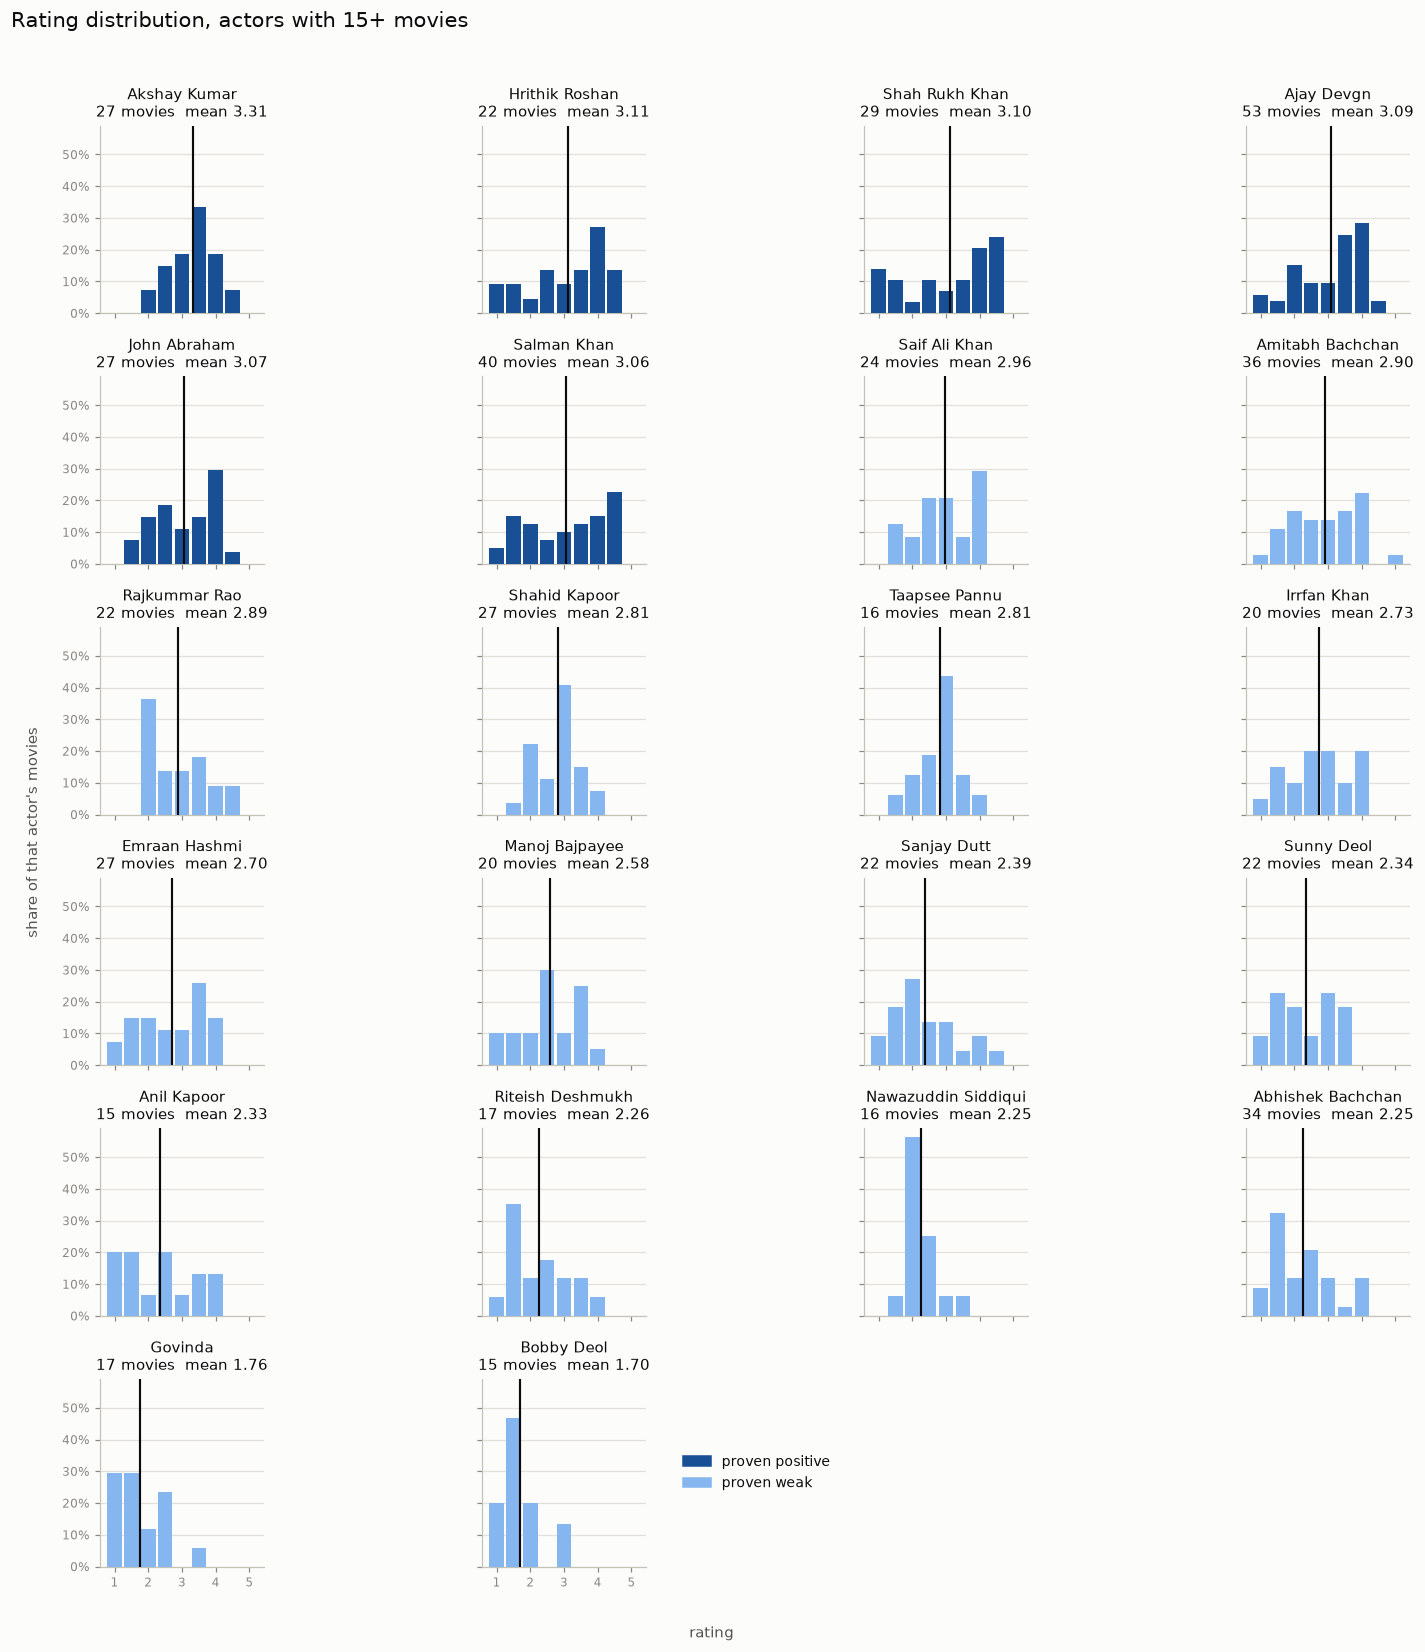

In [14]:
# Figure 4 - rating histogram per actor, for those with enough movies to shape one
BINS = np.arange(0.75, 5.51, 0.5)   # ratings sit on a 0.5 grid; one bin per value
proven = actors[actors.n_movies >= MIN_PROVEN].sort_values('mean_rating',
                                                           ascending=False)

ncol = 4
nrow = int(np.ceil(len(proven) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.5 * nrow),
                         sharex=True, sharey=True)

for ax, (name, row) in zip(axes.ravel(), proven.iterrows()):
    sub = df.loc[df.lead_actor == name, 'rating']
    # share of the actor's own filmography, so a 15-movie career and a
    # 53-movie one are on the same scale
    ax.hist(sub, bins=BINS, color=TIER_COLOR[row.tier], zorder=3, rwidth=0.86,
            weights=np.full(len(sub), 1 / len(sub)))
    ax.axvline(row.mean_rating, color=INK, lw=1.4, zorder=4)
    ax.set_title('%s\n%d movies  mean %.2f'
                 % (name, row.n_movies, row.mean_rating), fontsize=9.5, pad=6)
    ax.yaxis.grid(True); ax.xaxis.grid(False)
    ax.set_xticks(np.arange(1, 5.5, 1))
    ax.tick_params(labelsize=8)
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))

for ax in axes.ravel()[len(proven):]:
    ax.set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=TIER_COLOR[t])
           for t in ('proven_positive', 'proven_weak')]
axes.ravel()[len(proven) - 1].legend(
    handles, ['proven positive', 'proven weak'],
    loc='center left', bbox_to_anchor=(1.15, 0.5), frameon=False, fontsize=9)

fig.suptitle('Rating distribution, actors with %d+ movies' % MIN_PROVEN,
             fontsize=14, x=0.01, ha='left', y=0.998)
fig.supxlabel('rating', fontsize=10, color=INK2)
fig.supylabel("share of that actor's movies", fontsize=10, color=INK2)
fig.tight_layout(rect=(0.012, 0.012, 1, 0.985))
plt.show()

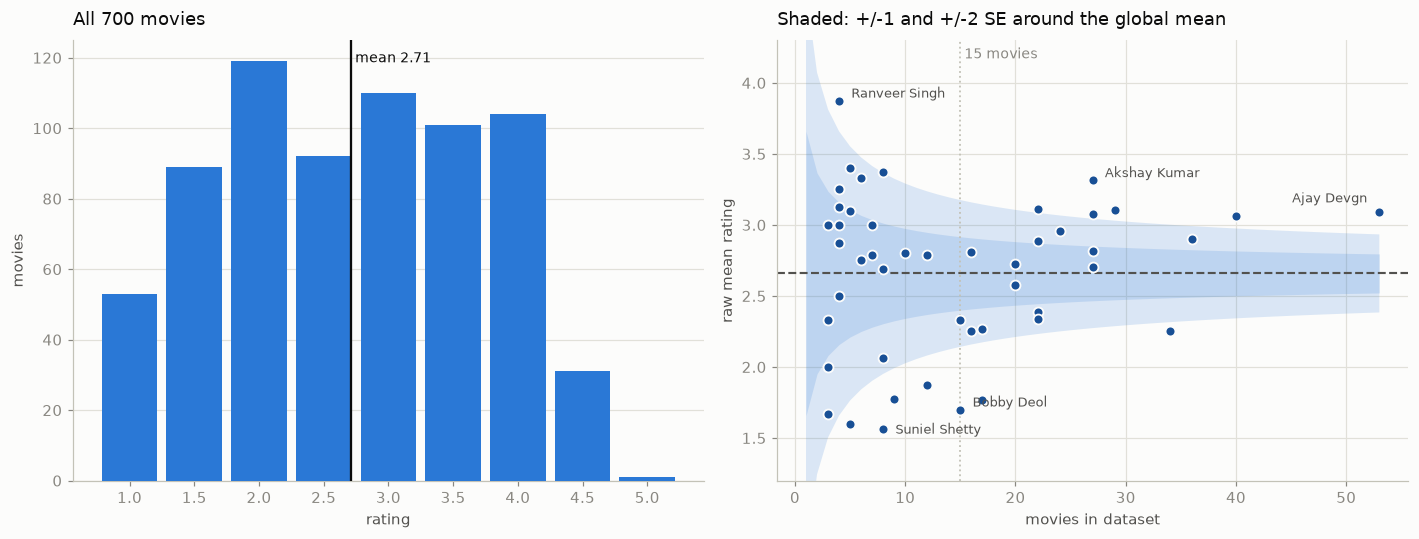

In [15]:
# Figure 5 - the overall distribution, and why small samples scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(df.rating, bins=BINS, color='#2a78d6', rwidth=0.86, zorder=3)
ax.axvline(MOVIE_MEAN, color=INK, lw=1.5, zorder=4)          # movie-level chart
ax.text(MOVIE_MEAN, ax.get_ylim()[1] * 0.95, ' mean %.2f' % MOVIE_MEAN,
        fontsize=9, color=INK)
ax.set_xticks(np.arange(1, 5.5, 0.5))
ax.set_xlabel('rating'); ax.set_ylabel('movies')
ax.set_title('All %d movies' % len(df), fontsize=12, loc='left', pad=10)
ax.yaxis.grid(True); ax.xaxis.grid(False)

ax = axes[1]
nn = np.arange(1, actors.n_movies.max() + 1)
# CAVEAT: df.rating.std() (1.000) mixes movie-to-movie noise WITH real
# actor-to-actor differences. The funnel asks "if this actor were exactly
# average, how much would their mean bounce?", which is within-actor noise only
# (sd 0.917). Using the pooled figure makes the band ~9% too wide, i.e. slightly
# conservative - it under-calls actors as distinguishable. Left as-is on purpose;
# tightening it is a separate decision.
pooled_sd = df.rating.std()
# funnel is centred on ACTOR_MEAN: the question is whether this ACTOR differs
# from an average actor, so the baseline is the actor-level average
for k in (2, 1):
    ax.fill_between(nn, ACTOR_MEAN - k * pooled_sd / np.sqrt(nn),
                    ACTOR_MEAN + k * pooled_sd / np.sqrt(nn),
                    color='#2a78d6', alpha=0.16, lw=0, zorder=1)
ax.axhline(ACTOR_MEAN, color=INK2, lw=1.4, ls='--', zorder=2)
ax.scatter(actors.n_movies, actors.mean_rating, s=42, color='#184f95',
           edgecolor=SURFACE, lw=1.2, zorder=3)

# hand-placed offsets: these five sit close enough to collide on autopilot
CALLOUTS = {'Ranveer Singh': (8, 2), 'Ajay Devgn': (-8, 6),
            'Akshay Kumar': (8, 2), 'Suniel Shetty': (8, -3),
            'Bobby Deol': (8, 2)}
for name, off in CALLOUTS.items():
    if name in actors.index:
        r = actors.loc[name]
        ax.annotate(name, (r.n_movies, r.mean_rating), fontsize=8.5,
                    color=INK2, xytext=off, textcoords='offset points',
                    ha='right' if off[0] < 0 else 'left')

ax.set_ylim(1.2, 4.3)
ax.axvline(MIN_PROVEN, color=AXIS, lw=1.2, ls=':', zorder=2)
ax.text(MIN_PROVEN, 4.25, ' %d movies' % MIN_PROVEN, fontsize=9,
        color=MUTED, va='top')
ax.set_xlabel('movies in dataset'); ax.set_ylabel('raw mean rating')
ax.set_title('Shaded: +/-1 and +/-2 SE around the global mean',
             fontsize=12, loc='left', pad=10)

fig.tight_layout()
plt.show()

# Anyone inside the shaded funnel is statistically indistinguishable from the
# dataset average - the band is wide at n=4 for exactly the reason Ranveer Singh
# needed pulling back.

# Is `rating` normally distributed within each actor?

For every actor with 15+ films, the normal N(μ, σ) sharing their mean and standard
deviation is drawn over their histogram, followed by the Q-Q plot that tests the fit.

**The caveat decides how to read everything below.** `rating` is **discrete** (nine values,
1.0-5.0 in 0.5 steps) and **bounded**, so the true distribution is not normal for anyone
here. Fitting one is still worth it: it puts μ and σ on the page, and it shows *how* each
actor departs - flat, skewed, or piled on one value. Figure 6 shades the part of each fitted
bell falling outside 1-5; for several actors that is **12-15%** of the distribution sitting
on ratings that cannot be awarded.

**On the test statistic.** Shapiro-Wilk needs `scipy`, which is not in this `.venv`. Each
panel reports **Filliben's r** instead - the correlation of the Q-Q points, so r = 1.000 is a
perfect line - against Filliben's published α = 0.05 critical values. Skew (0 = symmetric)
and excess kurtosis (0 = bell, negative = flatter) name the direction of the departure.


In [16]:
# --- normality toolkit: numpy + stdlib only, no scipy in this .venv -----------
from statistics import NormalDist

_SND = NormalDist()          # standard normal, for quantiles


def normal_pdf(x, mu, sd):
    """N(mu, sd) density over an array. Vectorised; NormalDist.pdf is scalar-only."""
    return np.exp(-0.5 * ((x - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))


def qq_points(x):
    """Blom plotting positions -> (theoretical z, sorted sample, Filliben's r).

    r is the correlation between the sorted sample and the normal quantiles it
    would land on if it were normal: 1.0 is a perfect straight line on a Q-Q
    plot, and departures pull it down.
    """
    xs = np.sort(np.asarray(x, dtype=float))
    n = len(xs)
    p = (np.arange(1, n + 1) - 0.375) / (n + 0.25)          # Blom
    th = np.array([_SND.inv_cdf(v) for v in p])
    return th, xs, float(np.corrcoef(th, xs)[0, 1])


# Filliben's published alpha = 0.05 critical values for r. Below the critical
# value for your n, reject normality. Interpolated because our n is not on the grid.
_FILL_N = [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
_FILL_CV = [.9179, .9383, .9503, .9582, .9639, .9682, .9715, .9740, .9764, .9783, .9800]


def filliben_crit(n):
    return float(np.interp(n, _FILL_N, _FILL_CV))


# verdict styling, shared by both figures below
PASS_MARK, FAIL_MARK = 'PASS', 'FAIL'
PASS_COLOR, FAIL_COLOR = '#1a7f4f', '#b5341f'

# --- one row per proven actor: the shape of their rating distribution ---------
rows = []
for name in proven.index:
    s = df.loc[df.lead_actor == name, 'rating']
    _, _, r = qq_points(s)
    mu, sd = s.mean(), s.std()
    nd = NormalDist(mu, sd)
    rows.append({
        'n': len(s), 'mean': mu, 'std': sd,
        'skew': s.skew(), 'kurt': s.kurt(),          # kurt is EXCESS kurtosis
        'filliben_r': r, 'crit05': filliben_crit(len(s)),
        # how much probability the fitted normal puts on ratings that cannot exist
        'leak_pct': 100 * (nd.cdf(1) + 1 - nd.cdf(5)),
    })
normality = pd.DataFrame(rows, index=proven.index)
normality['is_normal'] = normality.filliben_r >= normality.crit05

assert np.isfinite(normality.filliben_r).all(), 'a Filliben r came out non-finite'
assert len(normality) == len(proven)

print('Normality of rating within each actor (Filliben r vs alpha=0.05 critical value)')
print('kurt is EXCESS kurtosis: 0 = bell-shaped, negative = flatter, positive = peakier\n')
print(normality.assign(verdict=np.where(normality.is_normal, 'normal', 'NOT normal'))
      [['n', 'mean', 'std', 'skew', 'kurt', 'filliben_r', 'crit05', 'leak_pct', 'verdict']]
      .sort_values('filliben_r', ascending=False).round(3).to_string(), '\n')
print(normality.is_normal.value_counts()
      .rename({True: 'normal', False: 'NOT normal'}).to_string())


Normality of rating within each actor (Filliben r vs alpha=0.05 critical value)
kurt is EXCESS kurtosis: 0 = bell-shaped, negative = flatter, positive = peakier

                      n   mean    std   skew   kurt  filliben_r  crit05  leak_pct     verdict
lead_actor                                                                                   
Amitabh Bachchan     36  2.903  0.977 -0.052 -0.877       0.974   0.969     4.165      normal
Irrfan Khan          20  2.725  0.939 -0.152 -0.980       0.974   0.950     4.072      normal
Akshay Kumar         27  3.315  0.681 -0.246 -0.493       0.973   0.960     0.704      normal
Manoj Bajpayee       20  2.575  0.878 -0.318 -0.734       0.970   0.950     3.924      normal
Sanjay Dutt          22  2.386  0.975  0.648 -0.292       0.968   0.953     8.122      normal
Anil Kapoor          15  2.333  1.080  0.253 -1.325       0.965   0.938    11.530      normal
Taapsee Pannu        16  2.812  0.629 -0.323  0.305       0.962   0.941     0.224     

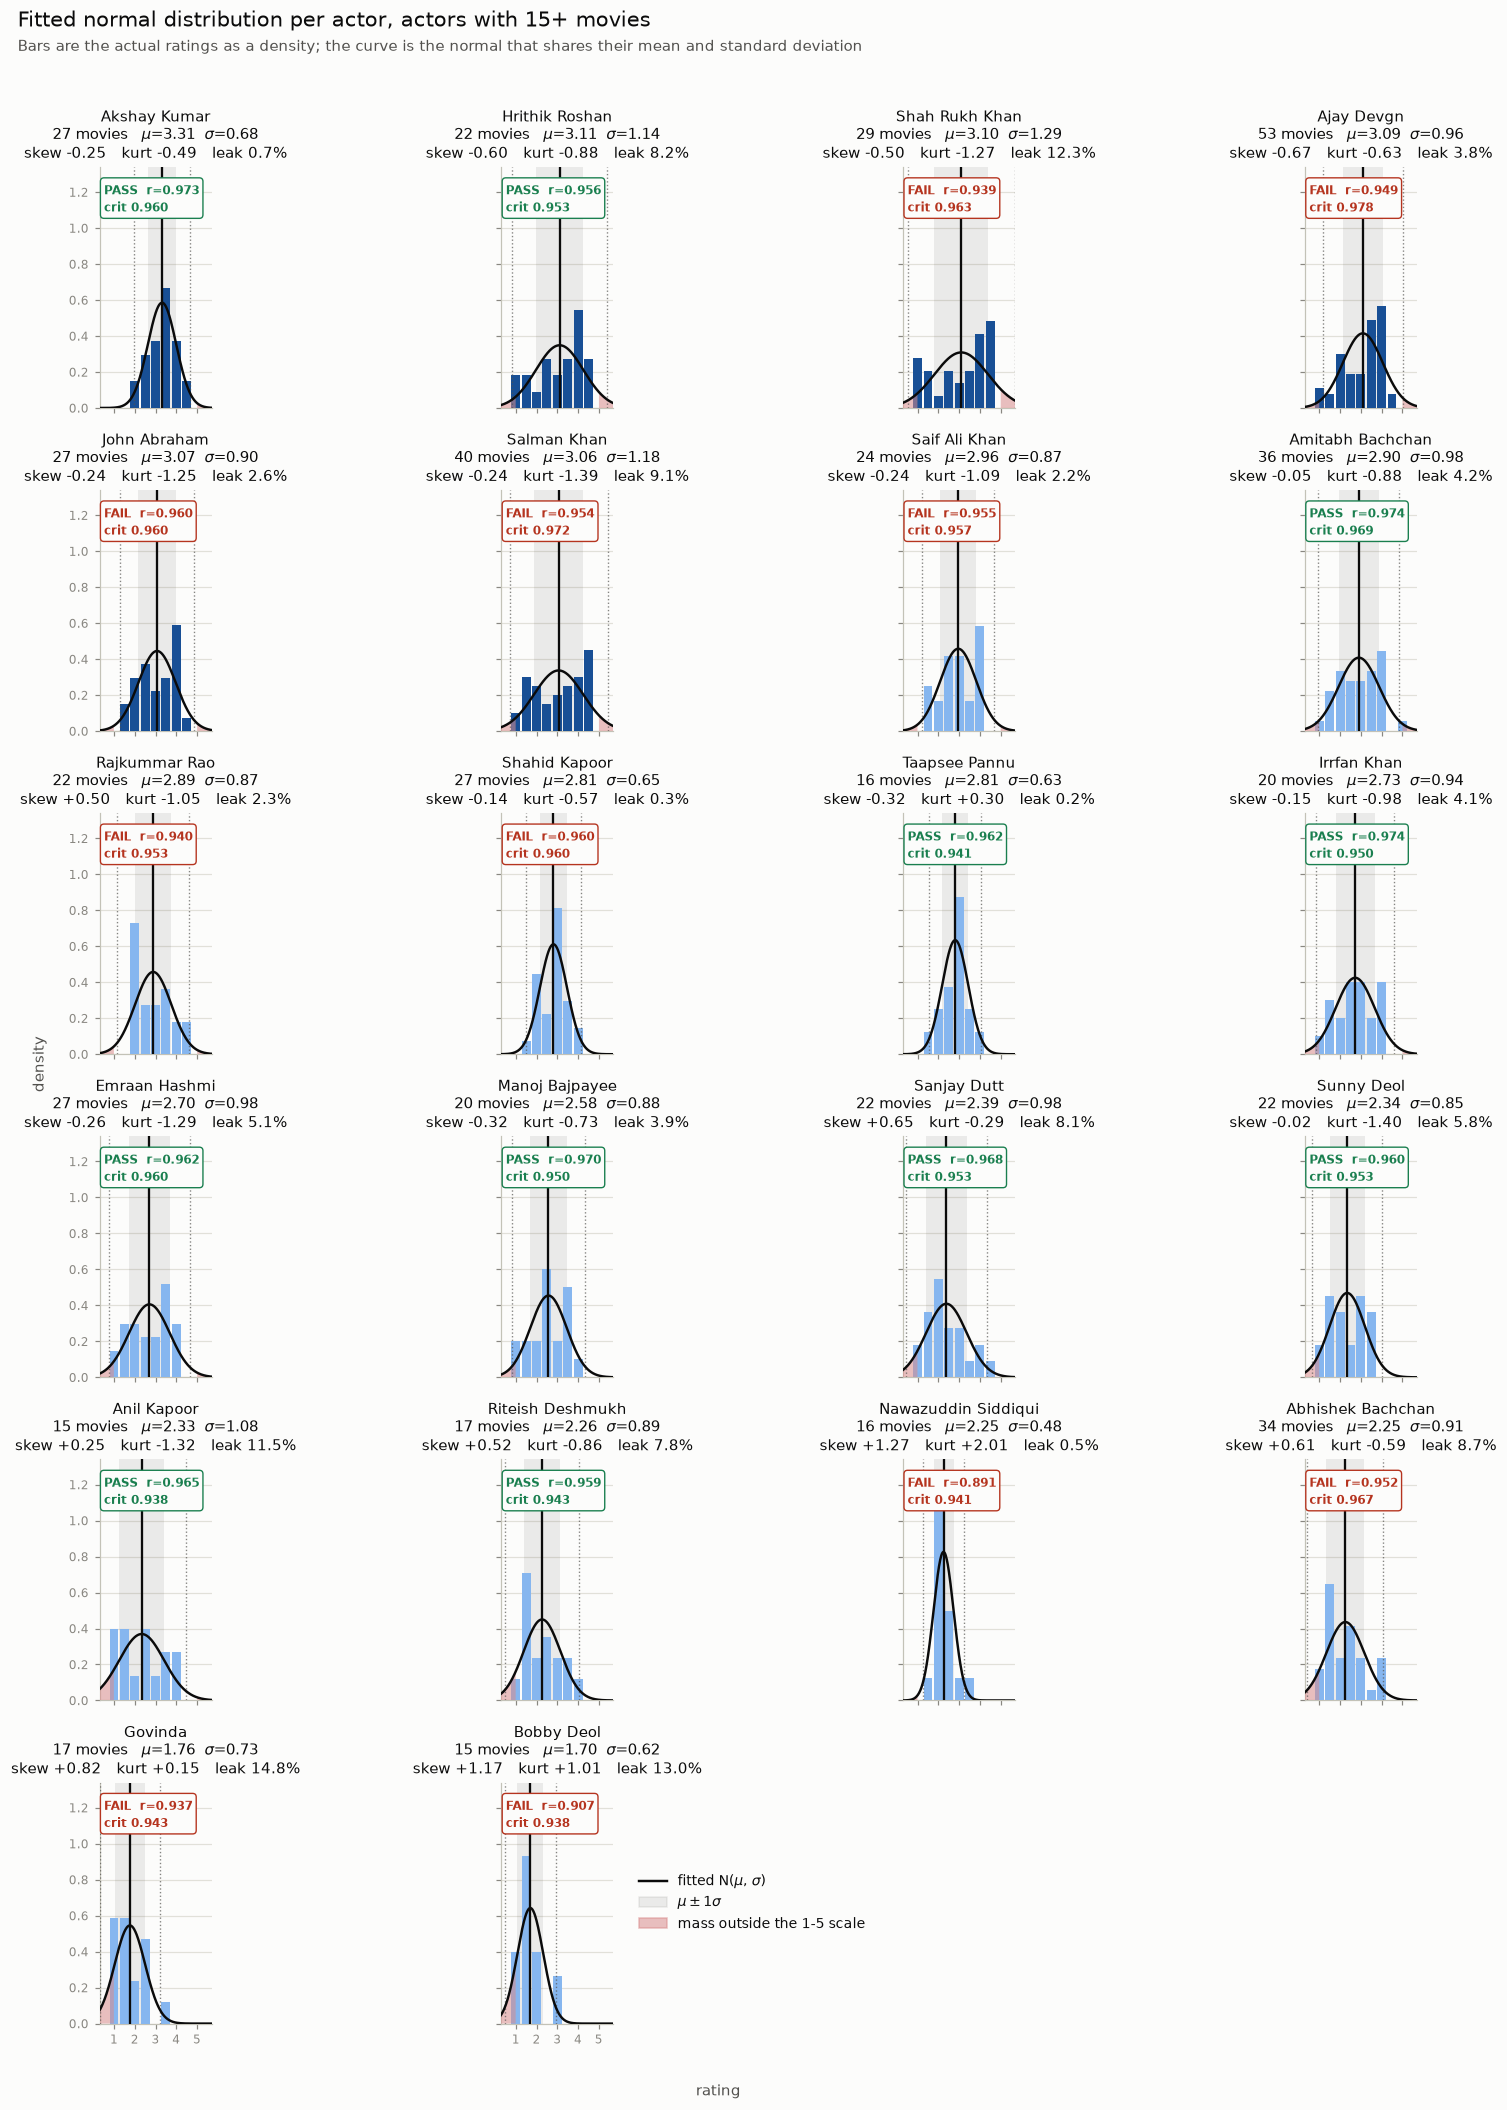

In [17]:
# Figure 6 - fitted normal curve over each actor's rating distribution
# Same actors, same order and same grid as Figure 4, so the two read as a pair.
# Figure 4 used weights= to show share-of-filmography; here the histogram is a
# DENSITY so the bars and the fitted curve live on the same y-scale.

XCURVE = np.linspace(0, 6, 400)     # runs past the 1-5 scale on purpose - see below
LEAK = '#d98c8c'                    # mass the normal puts where ratings cannot exist

ncol = 4
nrow = int(np.ceil(len(proven) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.2 * nrow),
                         sharex=True, sharey=True)

for ax, (name, row) in zip(axes.ravel(), proven.iterrows()):
    sub = df.loc[df.lead_actor == name, 'rating']
    st = normality.loc[name]
    mu, sd = st['mean'], st['std']

    ax.hist(sub, bins=BINS, density=True, color=TIER_COLOR[row.tier],
            rwidth=0.86, zorder=3)

    pdf = normal_pdf(XCURVE, mu, sd)
    ax.plot(XCURVE, pdf, color=INK, lw=1.6, zorder=6)
    # the part of the bell that falls outside the 1-5 scale: impossible ratings.
    # A normal is unbounded, the rating scale is not - this is the fit's error
    # made visible rather than argued about.
    ax.fill_between(XCURVE, 0, pdf, where=(XCURVE < 1) | (XCURVE > 5),
                    color=LEAK, alpha=0.55, lw=0, zorder=4, interpolate=True)

    ax.axvspan(mu - sd, mu + sd, color=INK2, alpha=0.10, lw=0, zorder=1)
    ax.axvline(mu, color=INK, lw=1.5, zorder=7)
    for s in (-2, 2):                              # +/-2 sigma markers
        ax.axvline(mu + s * sd, color=INK2, lw=0.9, ls=':', alpha=0.7, zorder=5)

    # the numbers that describe the shape go in the title, where nothing can
    # draw over them; only the compact verdict badge sits inside the panel
    ax.set_title('%s\n%d movies   $\\mu$=%.2f  $\\sigma$=%.2f\n'
                 'skew %+.2f   kurt %+.2f   leak %.1f%%'
                 % (name, st['n'], mu, sd, st['skew'], st['kurt'], st['leak_pct']),
                 fontsize=9.5, pad=6)

    ok = bool(st['is_normal'])
    ax.text(0.04, 0.94, '%s  r=%.3f\ncrit %.3f' %
            (PASS_MARK if ok else FAIL_MARK, st['filliben_r'], st['crit05']),
            transform=ax.transAxes, fontsize=7.8, va='top', ha='left',
            color=PASS_COLOR if ok else FAIL_COLOR, weight='bold',
            linespacing=1.4, zorder=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=SURFACE,
                      edgecolor=PASS_COLOR if ok else FAIL_COLOR, lw=0.9))

    ax.set_xlim(0.3, 5.7)
    ax.set_ylim(0, 1.34)                 # headroom so the badge clears the curve
    ax.set_xticks(np.arange(1, 5.5, 1))
    ax.tick_params(labelsize=8)
    ax.yaxis.grid(True); ax.xaxis.grid(False)

for ax in axes.ravel()[len(proven):]:
    ax.set_visible(False)

# legend explaining the two annotations that are not self-evident
handles = [plt.Line2D([], [], color=INK, lw=1.6, label='fitted N($\\mu$, $\\sigma$)'),
           plt.Rectangle((0, 0), 1, 1, color=INK2, alpha=0.10,
                         label='$\\mu \\pm 1\\sigma$'),
           plt.Rectangle((0, 0), 1, 1, color=LEAK, alpha=0.55,
                         label='mass outside the 1-5 scale')]
axes.ravel()[len(proven) - 1].legend(
    handles=handles, loc='center left', bbox_to_anchor=(1.12, 0.5),
    frameon=False, fontsize=9)

fig.suptitle('Fitted normal distribution per actor, actors with %d+ movies' % MIN_PROVEN,
             fontsize=14, x=0.01, ha='left', y=0.999)
fig.text(0.01, 0.985, 'Bars are the actual ratings as a density; the curve is the '
         'normal that shares their mean and standard deviation',
         fontsize=9.5, color=INK2, ha='left', va='top')
fig.supxlabel('rating', fontsize=10, color=INK2)
fig.supylabel('density', fontsize=10, color=INK2)
fig.tight_layout(rect=(0.012, 0.012, 1, 0.978))
plt.show()

# Where the pink is large (Govinda 14.8%, Bobby Deol 13.0%, Shah Rukh Khan 12.3%)
# the normal is spending an eighth of its probability on ratings that cannot be
# awarded - a concrete reason the fit is an approximation, not a description.
# Nawazuddin Siddiqui is the opposite case: sigma is so small (0.48) that almost
# nothing leaks, yet he is the worst fit in the set - his problem is skew, not spread.


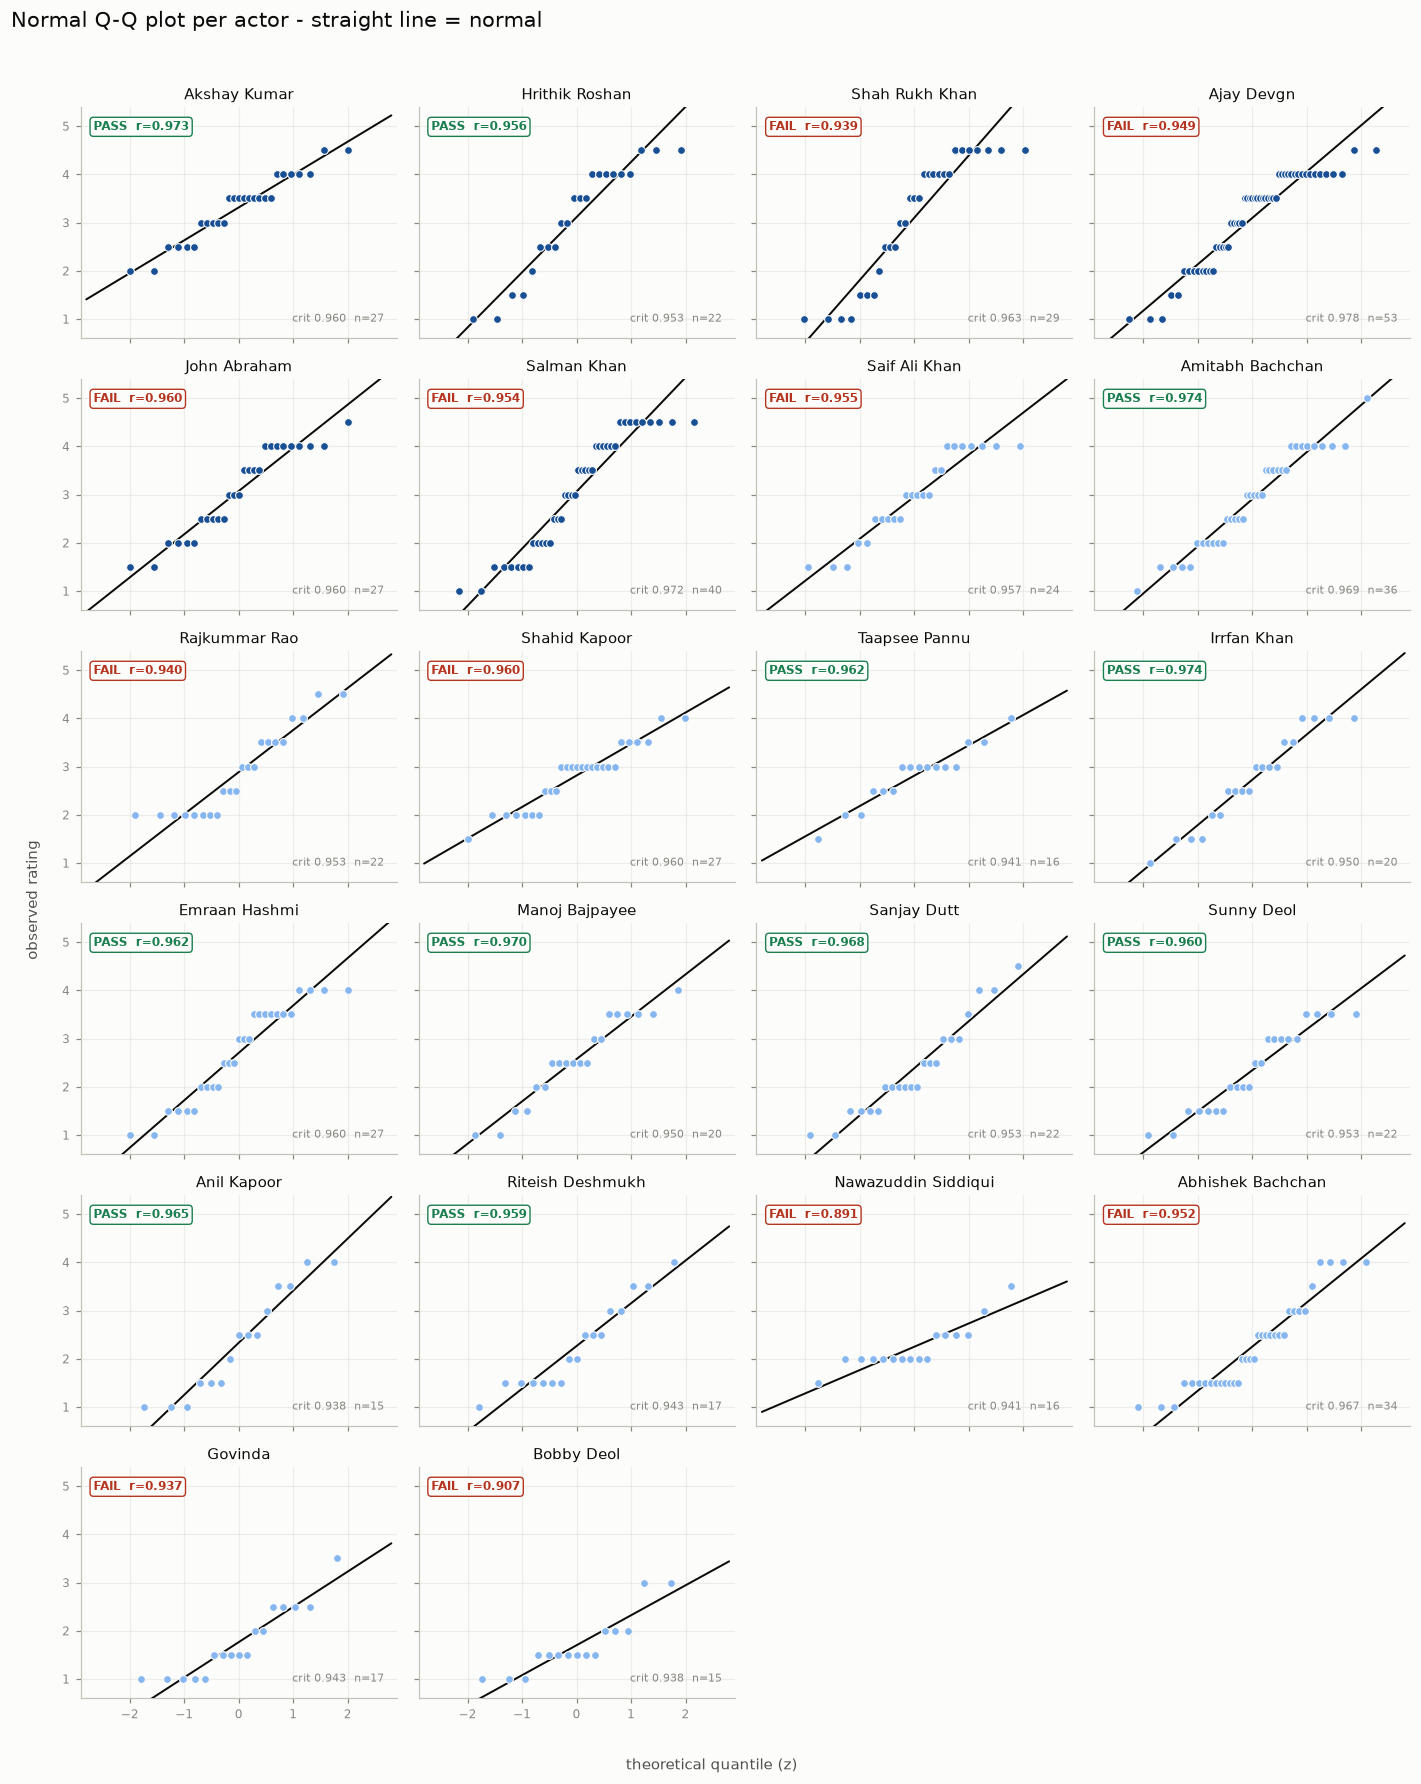

In [18]:
# Figure 7 - normal Q-Q plot per actor, same panels and same order as Figure 6
#
# READ THIS BEFORE READING THE PANELS: rating takes 9 discrete values, so many
# movies share a y-value and the points form HORIZONTAL STAIRCASES. That is the
# 0.5-point scale showing through, not evidence of non-normality. What matters
# is whether the staircase *tread centres* track the straight line or bend away
# from it - an S-bend means flat-tailed, a hook at one end means skew.

fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.7 * nrow),
                         sharex=True, sharey=True)

for ax, name in zip(axes.ravel(), proven.index):
    row = normality.loc[name]
    th, xs, _ = qq_points(df.loc[df.lead_actor == name, 'rating'])

    # reference line: where the points would sit if the fit were exact
    zline = np.linspace(-2.8, 2.8, 2)
    ax.plot(zline, row['mean'] + row['std'] * zline,
            color=INK, lw=1.3, zorder=3, solid_capstyle='round')

    ax.scatter(th, xs, s=26, color=TIER_COLOR[proven.loc[name, 'tier']],
               edgecolor=SURFACE, lw=0.7, zorder=4)

    ok = bool(row['is_normal'])
    ax.set_title(name, fontsize=9.5, pad=5)
    # verdict badge - colour carries the pass/fail so it reads at a glance
    ax.text(0.04, 0.94, '%s  r=%.3f' % (PASS_MARK if ok else FAIL_MARK, row['filliben_r']),
            transform=ax.transAxes, fontsize=8, va='top', ha='left',
            color=PASS_COLOR if ok else FAIL_COLOR, weight='bold',
            bbox=dict(boxstyle='round,pad=0.28', facecolor=SURFACE,
                      edgecolor=PASS_COLOR if ok else FAIL_COLOR, lw=0.9))
    ax.text(0.96, 0.06, 'crit %.3f  n=%d' % (row['crit05'], row['n']),
            transform=ax.transAxes, fontsize=7.5, va='bottom', ha='right',
            color=MUTED)

    ax.set_xlim(-2.9, 2.9)
    ax.set_ylim(0.6, 5.4)
    ax.set_yticks(np.arange(1, 5.5, 1))
    ax.set_xticks([-2, -1, 0, 1, 2])
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.55)

for ax in axes.ravel()[len(proven):]:
    ax.set_visible(False)

fig.suptitle('Normal Q-Q plot per actor - straight line = normal',
             fontsize=14, x=0.01, ha='left', y=0.999)
fig.supxlabel('theoretical quantile (z)', fontsize=10, color=INK2)
fig.supylabel('observed rating', fontsize=10, color=INK2)
fig.tight_layout(rect=(0.012, 0.012, 1, 0.986))
plt.show()

# Ajay Devgn and Shah Rukh Khan: points sag below the line at the left and rise
# above it at the right - the S-bend of a flat (platykurtic) distribution.
# Bobby Deol, Nawazuddin Siddiqui, Govinda: the low end hooks hard off the line,
# because the ratings are pinned against the floor of the scale.


## What the normality check says

**Eleven of 22 actors clear Filliben's 5% critical value, eleven do not - and the split is
not random.**

**Failures cluster at high `n`.** Ajay Devgn (53 films, r=0.949 vs 0.978), Salman Khan
(40, 0.954 vs 0.972), Abhishek Bachchan (34, 0.952 vs 0.967) and Shah Rukh Khan
(29, 0.939 vs 0.963) all fail - not because their ratings are stranger, but because the test
has more power to notice. Their excess kurtosis (-0.63, -1.39, -0.59, -1.27) says their
careers spread flat across the scale, and Figure 7 shows the matching S-bend.

**The other failure mode is skew at the weak end.** Nawazuddin Siddiqui (r=0.891, worst in
the set), Bobby Deol (0.907) and Govinda (0.937) pile up at 1.0-2.0 with a thin tail up -
skew +1.27, +1.17, +0.82. Note Siddiqui leaks only **0.5%** of his fitted mass out of bounds
(σ = 0.48, a narrow bell); he fails purely on shape. Skew and boundary-leak are separate
failures.

**Two are on the line.** John Abraham and Shahid Kapoor both land at r=0.960 against a
critical value of 0.960. Read them as undecided, not rejected.

**A pass is not proof of normality** - with 9 possible values on a bounded scale the true
distribution cannot be normal. A pass means only that the normal is not a badly wrong
approximation at this sample size.

**What this changes for modelling.** Do not assume Gaussian residuals. Do not z-score an
actor's rating - that transform holds worst for exactly the actors you most want to rank.
Prefer rank- or ordinal-based treatments, or `adj_mean`, which assumes no distribution.
Carry `actor_std_rating` with a caveat: where skew is large, σ is a poor summary of spread.


# The era confound

`n_movies` does not bias an actor's mean directly, but it is entangled with something that
does. **Long filmographies span more eras** - `corr(n_movies, career span) = 0.655` - and
ratings drift enormously across them:

```
2000-2004   2.01          2015-2019   2.87
2005-2009   2.51          2020-2024   3.01
2010-2014   3.26
```

A swing of more than a full point, larger than the gap between the best and worst actors
here. The chain runs: **more films -> longer career -> more exposure to the harsh early
2000s -> lower raw mean.** So `actor_mean_rating` silently encodes *when* someone worked
alongside *how good* they are.

**Is it the films or the reviewer?** Only two critics appear, and they hand over almost
exactly when ratings jump - Taran Adarsh covers 2000-2014, Bollywood Hungama News Network
2015 on. Era and critic are **confounded**. The trend does survive holding the critic fixed
(Adarsh alone runs 2.01 -> 2.51 -> 3.28 -> 3.55), so the drift is real, but its size is not
cleanly attributable.

**A Simpson's paradox worth seeing.** Pooled over all years Adarsh looks harsher
(2.593 vs 2.880); in the years both were active the comparison **reverses**
(3.301 vs 2.848). He only looks harsh because he covered the harsh era.

**What the correction does.** Re-ranking each film against its own year's mean leaves rank
correlation at 0.929 with **zero** tier changes - but the actors who move, move far, and all
in the predicted direction: Anil Kapoor +16 places, Shah Rukh Khan 9th -> 3rd, Govinda +6;
Rajkummar Rao -5, Nawazuddin Siddiqui -4.5.

**Read this as a diagnostic, not a correction to bake in.** It assumes a simple additive
shift, leans on year means from as few as a handful of films, and scrubs real signal along
with the era effect. `rating_vs_era` is carried *alongside* `rating`, never as a replacement.


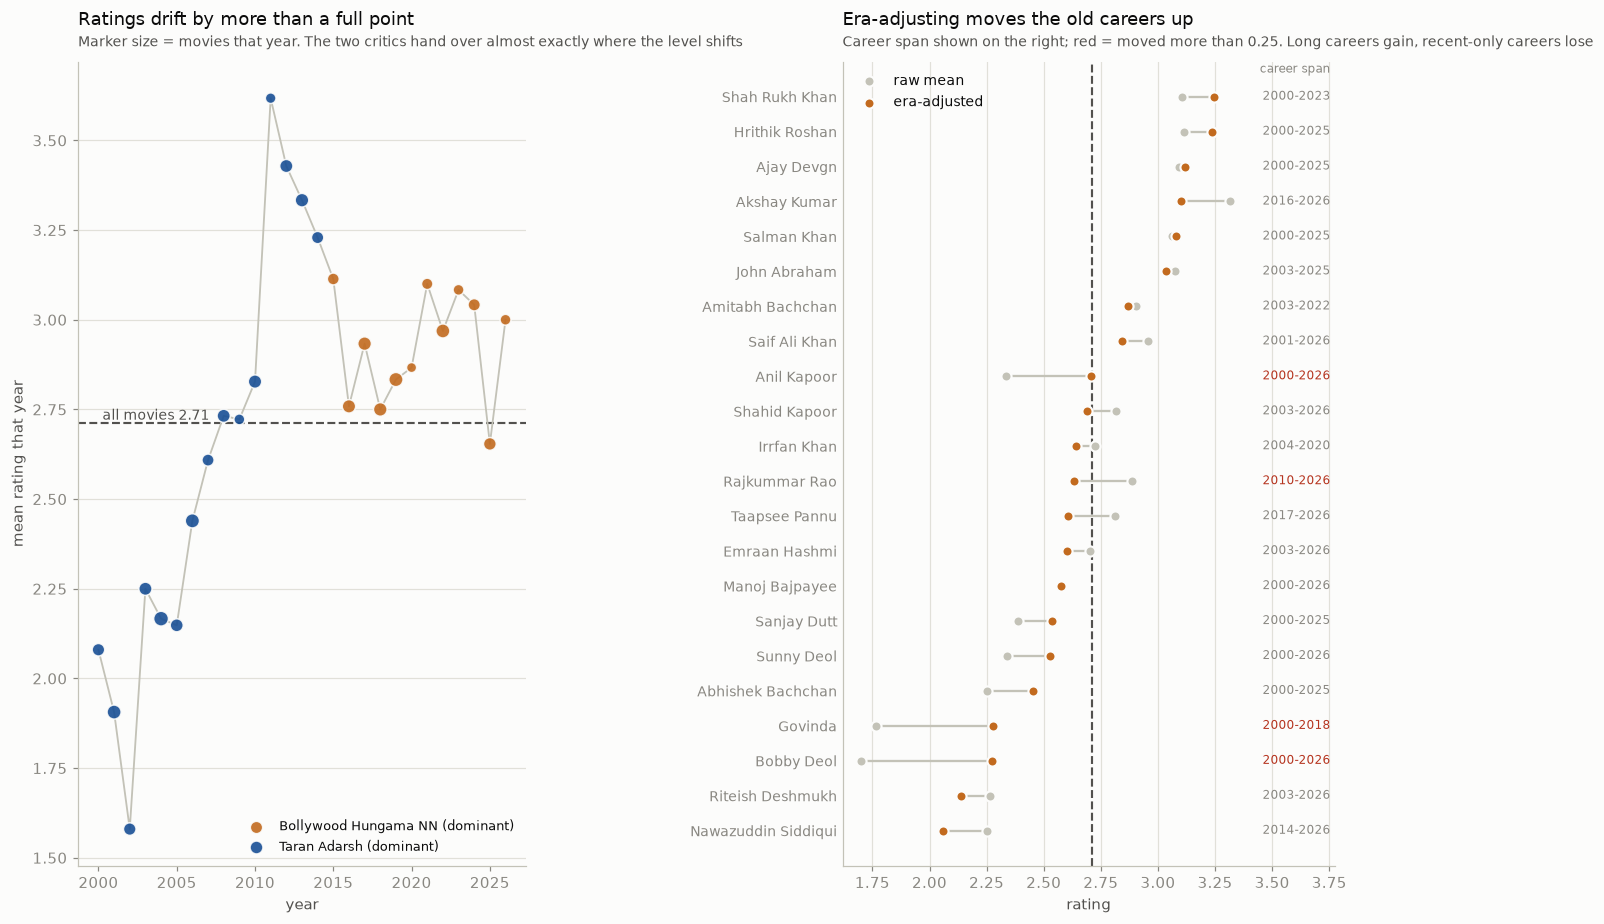

biggest era shifts among actors with 15+ movies:
                     n_movies  first_year  last_year  span  mean_rating  era_adj_mean  era_shift
lead_actor                                                                                      
Bobby Deol                 15        2000       2026    27         1.70          2.27       0.57
Govinda                    17        2000       2018    19         1.76          2.28       0.51
Anil Kapoor                15        2000       2026    27         2.33          2.71       0.38
Rajkummar Rao              22        2010       2026    17         2.89          2.63      -0.25
Akshay Kumar               27        2016       2026    11         3.31          3.10      -0.21
Abhishek Bachchan          34        2000       2025    26         2.25          2.45       0.20
Taapsee Pannu              16        2017       2026    10         2.81          2.61      -0.20
Nawazuddin Siddiqui        16        2014       2026    13         2.25       

In [19]:
# --- era confound: quantify it, then carry it as a separate feature ----------
CRIT_COLOR = {'Taran Adarsh': '#184f95',
              'Bollywood Hungama News Network': '#c26a1e'}

# score each movie against its OWN year rather than against all 700
df['year_mean'] = df.groupby('year')['rating'].transform('mean')
df['rating_vs_era'] = df['rating'] - df['year_mean']

# actor-level version, shifted back onto a readable 1-5 scale
actors['era_adj_mean'] = (df.groupby('lead_actor')['rating_vs_era'].mean()
                          + MOVIE_MEAN)
actors['era_shift'] = actors.era_adj_mean - actors.mean_rating

assert abs(df.rating_vs_era.mean()) < 1e-9, 'residuals must centre on zero'
assert actors.era_adj_mean.notna().all(), 'an actor lost their era-adjusted mean'

yr = df.groupby('year').agg(n=('rating', 'size'), mean=('rating', 'mean'))
yr['critic'] = (df.groupby(['year', 'critic']).size()
                  .unstack(fill_value=0).idxmax(axis=1))      # who dominated that year

fig, axes = plt.subplots(1, 2, figsize=(14, 8.5),
                         gridspec_kw={'width_ratios': [1, 1.1]})

# --- left: the drift itself, with the critic handover made visible -----------
ax = axes[0]
ax.plot(yr.index, yr['mean'], color=AXIS, lw=1.2, zorder=2)
for crit, sub in yr.groupby('critic'):
    ax.scatter(sub.index, sub['mean'], s=8 + 2.4 * sub.n, color=CRIT_COLOR[crit],
               edgecolor=SURFACE, lw=1.0, zorder=3, alpha=0.9,
               label='%s (dominant)' % crit.replace(' News Network', ' NN'))
ax.axhline(MOVIE_MEAN, color=INK2, lw=1.4, ls='--', zorder=1)
ax.text(yr.index.min(), MOVIE_MEAN, ' all movies %.2f' % MOVIE_MEAN,
        fontsize=9, color=INK2, va='bottom')
ax.set_xlabel('year'); ax.set_ylabel('mean rating that year')
ax.set_title('Ratings drift by more than a full point', fontsize=12, loc='left', pad=24)
ax.text(0, 1.015, 'Marker size = movies that year. The two critics hand over '
        'almost exactly where the level shifts', transform=ax.transAxes,
        fontsize=9, color=INK2, va='bottom')
ax.legend(loc='lower right', frameon=False, fontsize=8.5)
ax.yaxis.grid(True); ax.xaxis.grid(False)

# --- right: who the correction actually moves -------------------------------
ax = axes[1]
mv = actors[actors.n_movies >= MIN_PROVEN].sort_values('era_adj_mean')
ypos = np.arange(len(mv))
for y, (_, row) in zip(ypos, mv.iterrows()):
    ax.plot([row.mean_rating, row.era_adj_mean], [y, y],
            color=AXIS, lw=1.5, zorder=2, solid_capstyle='round')
ax.scatter(mv.mean_rating, ypos, s=44, color=AXIS, edgecolor=SURFACE, lw=1.4,
           zorder=3, label='raw mean')
ax.scatter(mv.era_adj_mean, ypos, s=44, color='#c26a1e', edgecolor=SURFACE,
           lw=1.4, zorder=4, label='era-adjusted')
ax.axvline(MOVIE_MEAN, color=INK2, lw=1.4, ls='--', zorder=1)

ax.set_yticks(ypos); ax.set_yticklabels(mv.index, fontsize=9)
ax.set_ylim(-1, len(mv))
ax.set_xlabel('rating'); ax.tick_params(axis='y', length=0)
ax.set_title('Era-adjusting moves the old careers up', fontsize=12, loc='left', pad=24)
ax.text(0, 1.015, 'Career span shown on the right; red = moved more than 0.25. '
        'Long careers gain, recent-only careers lose', transform=ax.transAxes,
        fontsize=9, color=INK2, va='bottom')
# top-left is empty (high rows sit at high ratings), so the legend goes there
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.xaxis.grid(True); ax.yaxis.grid(False)

# reserve a clear column on the right for career spans instead of letting them
# land on top of the marks
lo, hi = ax.get_xlim()
ax.set_xlim(lo, hi + 0.38)
for y, (_, row) in zip(ypos, mv.iterrows()):
    ax.text(hi + 0.36, y, '%d-%d' % (row.first_year, row.last_year), va='center',
            ha='right', fontsize=7.6,
            color=FAIL_COLOR if abs(row.era_shift) > 0.25 else MUTED)
ax.text(hi + 0.36, len(mv) - 0.4, 'career span', va='bottom', ha='right',
        fontsize=7.8, color=MUTED)

fig.tight_layout()
plt.show()

print('biggest era shifts among actors with %d+ movies:' % MIN_PROVEN)
print(actors[actors.n_movies >= MIN_PROVEN]
      .assign(span=lambda t: t.last_year - t.first_year + 1)
      [['n_movies', 'first_year', 'last_year', 'span',
        'mean_rating', 'era_adj_mean', 'era_shift']]
      .sort_values('era_shift', key=abs, ascending=False).head(8).round(2).to_string())


## What the per-actor view says

**Six actors are proven positive** - 15+ films *and* a mean above 3: Akshay Kumar (27, 3.31),
Hrithik Roshan (22, 3.11), Shah Rukh Khan (29, 3.10), Ajay Devgn (53, 3.09), John Abraham
(27, 3.07), Salman Khan (40, 3.06). Only these means are backed by enough films to bet on.

**Seven look strong on too little evidence.** Ranveer Singh's raw 3.88 is the highest number
in the dataset and comes from four films; Aamir Khan (5), Ranbir Kapoor (8) and Priyanka
Chopra Jonas (6) are the same story. Treat the whole `promising` tier as a hypothesis.

**The weak end is more reliable.** Bobby Deol (15, 1.70), Govinda (17, 1.76), Riteish
Deshmukh (17, 2.26), Nawazuddin Siddiqui (16, 2.25) and Abhishek Bachchan (34, 2.25) all
have the sample size to make a low mean stick, and sit outside ±2 SE of the global mean.

**Spread matters as much as the mean.** Amitabh Bachchan (36 films) ranges the full 1.0-5.0;
Taapsee Pannu's 16 pile up on 2.5. Same mean does not mean interchangeable, so carry
`std_rating` alongside `adj_mean`.

**Era hides inside the actor features** - see the section above. Carry `rating_vs_era`
alongside `rating`, noting era is confounded with the critic changeover.

**Carry forward:** `adj_mean`, `n_movies`, `std_rating`, `tier` - all recomputed out-of-fold.
Never `rating`, and never `actor_mean_rating` computed on the full dataset.
